<a href="https://colab.research.google.com/github/anant060806/Quantum-Computing/blob/main/quantum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

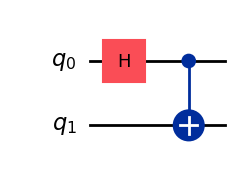

In [ ]:
from qiskit import QuantumCircuit
q=QuantumCircuit(2)
q.h(0)
q.cx(0,1)
q.draw(output='mpl')

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token="HnW7tVvxK30X52486yTJEXa0pjtnt9uUZqFY8miBM-c",
    overwrite=True
)

In [ ]:
from qiskit.quantum_info import Pauli
zi=Pauli("ZI")
iz=Pauli("IZ")
xi=Pauli("XI")
yi=Pauli("YI")
ix=Pauli("IX")
iy=Pauli("IY")
observ=[zi,iz,xi,ix,yi,iy]

In [ ]:
from qiskit_aer.primitives import Estimator
est=Estimator()
j=est.run([q]*len(observ),observ)
j.result()

EstimatorResult(values=array([ 0.04296875,  0.04296875,  0.01171875,  0.01171875,  0.05664062,
       -0.05664062]), metadata=[{'shots': 1024, 'variance': 0.9981536865234375, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0060849, 'sample_measure_time': 0.0006857, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 15989, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 18, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9981536865234375, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0060849, 'sample_measur

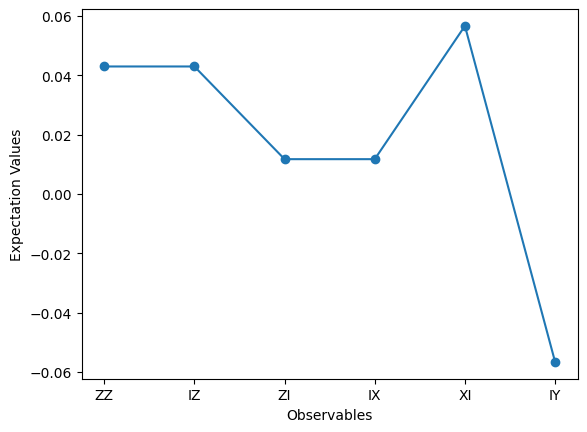

In [ ]:
import matplotlib.pyplot as pl

d = ['ZZ','IZ','ZI','IX','XI','IY','YI']

values = j.result().values.real

d = d[:len(values)]

pl.plot(d, values, '-o')
pl.xlabel("Observables")
pl.ylabel("Expectation Values")
pl.show()

## nigga lets work now


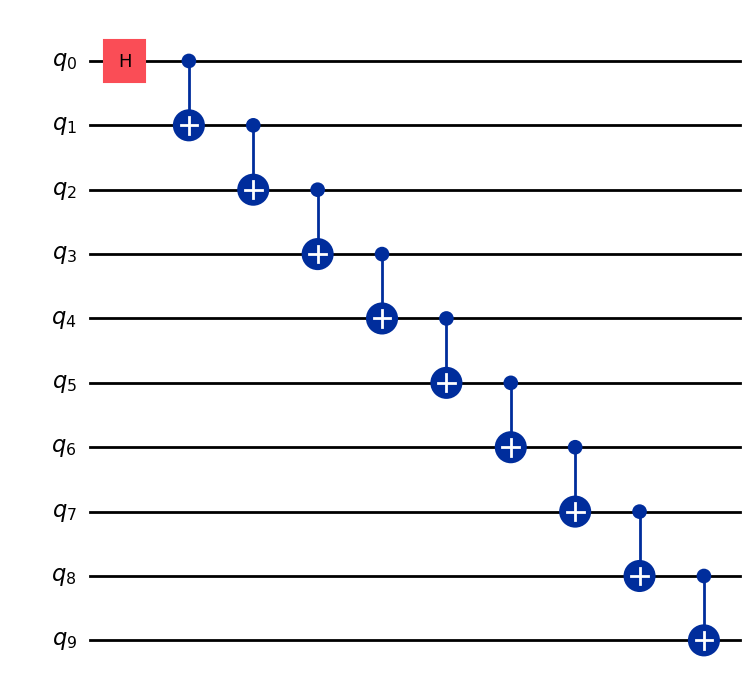

In [ ]:
from qiskit import QuantumCircuit
def qc_niga(n):
    q=QuantumCircuit(n)
    q.h(0)

    for i in range(n-1):
      q.cx(i,i+1)

    return q


v=qc_niga(10)
v.draw(output='mpl')

In [ ]:
from qiskit.quantum_info import SparsePauliOp
n=q.num_qubits
op_string=['Z'+'I'*i+'Z'+'I'*(n-2-i) for i in range(n-1)]
print(op_string)
operators=[SparsePauliOp(op_string) for op_string in op_string]

['ZZ']


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token="S2K_v9X_536STqZGsCCPs_PMDlJBs7gP2htbPOabPpSt",
    overwrite=True
)

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-06-05 11:31:37,109: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


## DAMN



In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService()

backend = service.backend("ibm_kingston")

pass_manager = generate_preset_pass_manager(
    optimization_level=1,
    backend=backend
)

q_trans = pass_manager.run(q)
operator_trans=[op.apply_layout(q_trans.layout) for op in operators]

qiskit_runtime_service.__init__:WARNING:2026-06-05 11:48:27,926: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-05 11:48:27,927: Using instance: open-instance, plan: open


## execute it now


In [ ]:
from qiskit_ibm_runtime import EstimatorV2 as est ## estiamtor
from qiskit_ibm_runtime import EstimatorOptions

options =EstimatorOptions()
options.resilience_level=1
options.optimization_level=0
options.dynamical_decoupling.enable=True
options.dynamical_decoupling.sequence_type="XY4"
est=Estimator(backend,options=options)

job=est.run([qc_niga,op_string])
